Gen 0, Best = 25408.73
Gen 50, Best = 20473.39
Gen 100, Best = 18261.04
Gen 150, Best = 18261.04
Gen 200, Best = 18261.04
Gen 250, Best = 18084.21
Gen 300, Best = 17620.21
Gen 350, Best = 17444.45
Gen 400, Best = 17444.45
Gen 450, Best = 17435.47
Gen 500, Best = 16495.91
Gen 550, Best = 7987.45
Gen 600, Best = 7360.88
Gen 650, Best = 7360.88
Gen 700, Best = 7360.88
Gen 750, Best = 7360.88
Gen 800, Best = 7360.88
Gen 850, Best = 7360.88
Gen 900, Best = 7360.88
Gen 950, Best = 7360.88
Gen 1000, Best = 7360.88
Gen 1050, Best = 7360.88
Gen 1100, Best = 7360.88
Gen 1150, Best = 7360.88
Gen 1200, Best = 7360.88
Gen 1250, Best = 7360.88
Gen 1300, Best = 7360.88
Gen 1350, Best = 7360.88
Gen 1400, Best = 7360.88
Gen 1450, Best = 7360.88
Gen 1500, Best = 7360.88
Gen 1550, Best = 7360.88
Gen 1600, Best = 7360.88
Gen 1650, Best = 7360.88
Gen 1700, Best = 7360.88
Gen 1750, Best = 7360.88
Gen 1800, Best = 7360.88
Gen 1850, Best = 7360.88
Gen 1900, Best = 7360.88
Gen 1950, Best = 7360.88
Gen 2000, Be

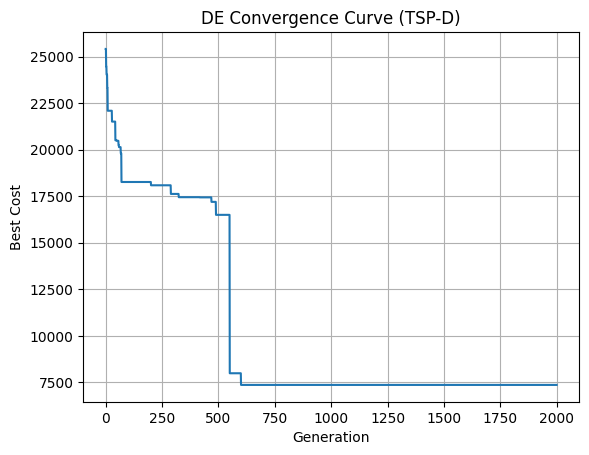

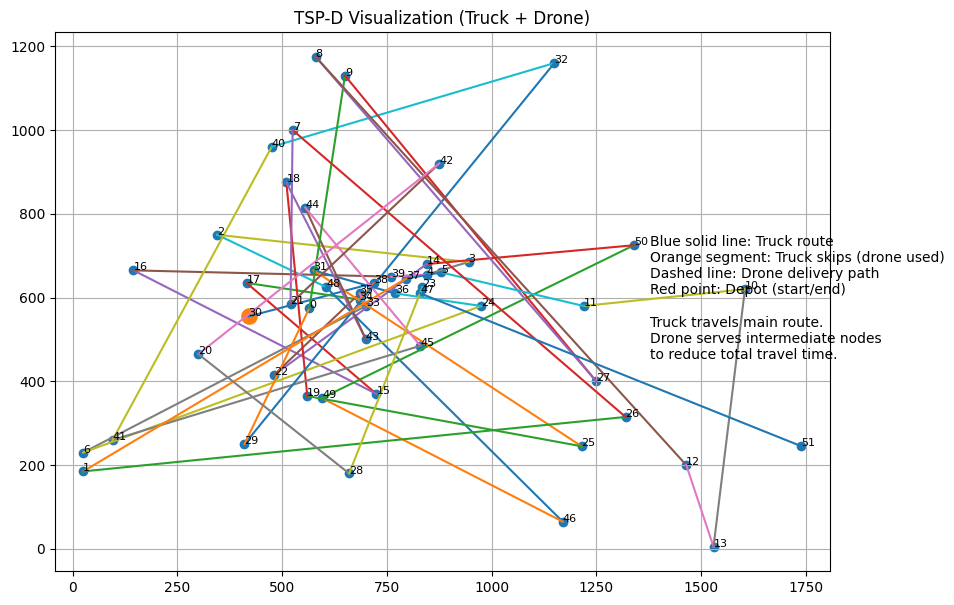


===== RUNNING 60 DE EXPERIMENTS =====
Run 1/60
Gen 0, Best = 25285.66
Gen 50, Best = 19647.94
Gen 100, Best = 17997.96
Gen 150, Best = 16870.42
Gen 200, Best = 16640.90
Gen 250, Best = 15998.09
Gen 300, Best = 15998.09
Gen 350, Best = 15870.81
Gen 400, Best = 15870.81
Gen 450, Best = 15528.93
Gen 500, Best = 15528.93
Gen 550, Best = 8039.60
Gen 600, Best = 7656.40
Gen 650, Best = 7656.40
Gen 700, Best = 7656.40
Gen 750, Best = 7656.40
Gen 800, Best = 7656.40
Gen 850, Best = 7656.40
Gen 900, Best = 7656.40
Gen 950, Best = 7656.40
Gen 1000, Best = 7656.40
Gen 1050, Best = 7656.40
Gen 1100, Best = 7656.40
Gen 1150, Best = 7656.40
Gen 1200, Best = 7656.40
Gen 1250, Best = 7656.40
Gen 1300, Best = 7656.40
Gen 1350, Best = 7656.40
Gen 1400, Best = 7656.40
Gen 1450, Best = 7656.40
Gen 1500, Best = 7656.40
Gen 1550, Best = 7656.40
Gen 1600, Best = 7656.40
Gen 1650, Best = 7656.40
Gen 1700, Best = 7656.40
Gen 1750, Best = 7656.40
Gen 1800, Best = 7656.40
Gen 1850, Best = 7656.40
Gen 1900, Best

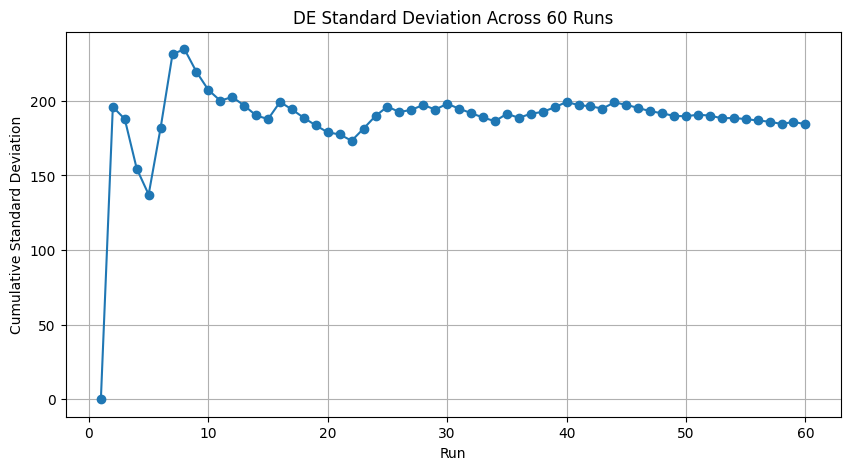

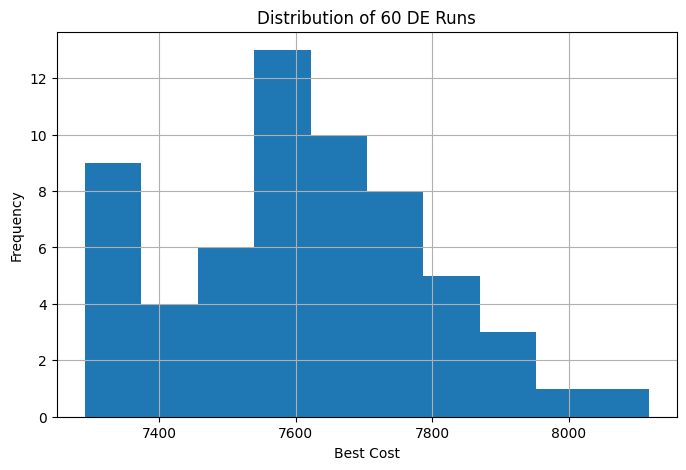

In [1]:
import numpy as np

# =========================
# READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)


# =========================
# DIST MATRIX
# =========================
def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist


# =========================
# DECODE
# =========================
def decode(ind):
    return np.argsort(ind)


# =========================
# TSP-D COST
# =========================
DRONE_RANGE = 200
DRONE_SPEED = 1.5
TRUCK_SPEED = 1.0
WAIT_TIME = 5

def tspd_cost(route, dist):
    total = 0.0
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]

            saving = dist[a][b] + dist[b][c] - dist[a][c]

            if drone_dist <= DRONE_RANGE and saving > 5:
                total += max(truck_dist/TRUCK_SPEED,
                             drone_dist/DRONE_SPEED) + WAIT_TIME
                i += 2
                continue

        total += dist[a][b]
        i += 1

    return total


# =========================
# 2-OPT
# =========================
def two_opt(route, dist, max_iter=10):
    best = route.copy()
    best_cost = tspd_cost(best, dist)

    for _ in range(max_iter):
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+2, len(route)):
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]

                new_cost = tspd_cost(new_route, dist)

                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True

        if not improved:
            break

    return best


# =========================
# DE MAIN
# =========================
def DE_tspd(coords, NP=60, F=0.8, CR=0.9, GEN=2000):

    dist = compute_dist_matrix(coords)
    N = len(coords)

    pop = np.random.rand(NP, N)
    fitness_vals = np.array([tspd_cost(decode(ind), dist) for ind in pop])

    best_idx = np.argmin(fitness_vals)
    best_cost = fitness_vals[best_idx]
    history = []
    best_sol = pop[best_idx].copy()

    print(f"Gen 0, Best = {best_cost:.2f}")

    for g in range(1, GEN + 1):
        for i in range(NP):
            idxs = [j for j in range(NP) if j != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            v = np.clip(r1 + F * (r2 - r3), 0, 1)

            u = pop[i].copy()
            j_rand = np.random.randint(N)

            for j in range(N):
                if np.random.rand() < CR or j == j_rand:
                    u[j] = v[j]

            u_cost = tspd_cost(decode(u), dist)

            if u_cost < fitness_vals[i]:
                pop[i] = u
                fitness_vals[i] = u_cost

        # ===== UPDATE BEST =====
        idx = np.argmin(fitness_vals)
        if fitness_vals[idx] < best_cost:
            best_cost = fitness_vals[idx]
            best_sol = pop[idx].copy()
        history.append(best_cost)
        # ===== PHASE SWITCH =====
        # Sau 500 gen mới bật 2-opt
        if g > 500 and g % 50 == 0:
            route = decode(best_sol)
            route = two_opt(route, dist)
            cost = tspd_cost(route, dist)

            if cost < best_cost:
                best_cost = cost
                best_sol = route

        # ===== LOG =====
        if g % 50 == 0:
            print(f"Gen {g}, Best = {best_cost:.2f}")

    return decode(best_sol), best_cost, history

import matplotlib.pyplot as plt

def plot_convergence(history):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best Cost")
    plt.title("DE Convergence Curve (TSP-D)")
    plt.grid()
    plt.show()

def visualize_tspd(coords, route, dist):
    import matplotlib.pyplot as plt

    DRONE_RANGE = 200
    DRONE_SPEED = 1.5
    TRUCK_SPEED = 1.0
    WAIT_TIME = 5

    plt.figure(figsize=(10, 7))

    route_coords = coords[route]

    # ===== VẼ NODE =====
    plt.scatter(coords[:, 0], coords[:, 1])

    # depot
    plt.scatter(route_coords[0, 0], route_coords[0, 1], s=120)

    # ===== DUYỆT ROUTE =====
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]
            saving = dist[a][b] + dist[b][c] - dist[a][c]

            # ===== DÙNG DRONE =====
            if drone_dist <= DRONE_RANGE and saving > 5:

                # 🚚 truck đi A → C (cam)
                plt.plot([coords[a][0], coords[c][0]],
                         [coords[a][1], coords[c][1]])

                # 🚁 drone đi A → B
                plt.plot([coords[a][0], coords[b][0]],
                         [coords[a][1], coords[b][1]],
                         linestyle='dashed')

                # 🚁 drone đi B → C
                plt.plot([coords[b][0], coords[c][0]],
                         [coords[b][1], coords[c][1]],
                         linestyle='dashed')

                i += 2
                continue

        # ===== TRUCK BÌNH THƯỜNG =====
        plt.plot([coords[a][0], coords[b][0]],
                 [coords[a][1], coords[b][1]])

        i += 1

    # ===== LABEL NODE =====
    for idx in route:
        x, y = coords[idx]
        plt.text(x, y, str(idx), fontsize=8)

    # ===== LEGEND GIẢI THÍCH =====
    explanation = (
        "Blue solid line: Truck route\n"
        "Orange segment: Truck skips (drone used)\n"
        "Dashed line: Drone delivery path\n"
        "Red point: Depot (start/end)\n\n"
        "Truck travels main route.\n"
        "Drone serves intermediate nodes\n"
        "to reduce total travel time."
    )

    plt.gcf().text(0.72, 0.5, explanation, fontsize=10, va='center')

    # ===== FORMAT =====
    plt.title("TSP-D Visualization (Truck + Drone)")
    plt.axis('equal')
    plt.grid()

    plt.show()
def visualize_std_60_runs_de(coords, runs=60):
    """
    Chạy DE 60 lần và vẽ độ lệch chuẩn
    """
    all_costs = []

    print("\n===== RUNNING 60 DE EXPERIMENTS =====")
    for run in range(runs):
        print(f"Run {run+1}/{runs}")

        _, best_cost, _ = DE_tspd(
            coords,
            NP=60,
            F=0.8,
            CR=0.9,
            GEN=2000
        )

        all_costs.append(best_cost)

    all_costs = np.array(all_costs)

    # ===== THỐNG KÊ =====
    mean_cost = np.mean(all_costs)
    std_cost = np.std(all_costs, ddof=1)

    print("\n===== 60 RUNS DE STATISTICS =====")
    print(f"Mean = {mean_cost:.2f}")
    print(f"Std  = {std_cost:.2f}")
    print(f"Min  = {np.min(all_costs):.2f}")
    print(f"Max  = {np.max(all_costs):.2f}")

    # ===== STD TÍCH LŨY =====
    cumulative_std = []
    for i in range(1, len(all_costs) + 1):
        if i == 1:
            cumulative_std.append(0)
        else:
            cumulative_std.append(np.std(all_costs[:i], ddof=1))

    # ===== VẼ ĐỒ THỊ STD =====
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, runs + 1), cumulative_std, marker='o')
    plt.xlabel("Run")
    plt.ylabel("Cumulative Standard Deviation")
    plt.title("DE Standard Deviation Across 60 Runs")
    plt.grid(True)
    plt.show()

    # ===== HISTOGRAM =====
    plt.figure(figsize=(8, 5))
    plt.hist(all_costs, bins=10)
    plt.xlabel("Best Cost")
    plt.ylabel("Frequency")
    plt.title("Distribution of 60 DE Runs")
    plt.grid(True)
    plt.show()

    return all_costs
# =========================
# MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost, history = DE_tspd(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

    dist = compute_dist_matrix(coords)
    plot_convergence(history)
    visualize_tspd(coords, best_route, dist)

    run_costs = visualize_std_60_runs_de(coords, runs=60)